# PDEInvBench Data Inspection

This notebook is a short tutorial showing how to download PDEInvBench sample files from Hugging Face, open the HDF5 files with `h5py`, inspect their keys and shapes, and visualize a few representative fields.

## 1. Reaction Diffusion 2D

Reaction Diffusion models two coupled chemical species with FitzHugh-Nagumo dynamics. The data contains pattern-forming trajectories for the activator `u` and inhibitor `v`, with parameters encoded in the filename.

File keys: top-level keys like `0000`, `0001`, ... are different trajectories for the same parameter setting. Inside each trajectory, `data` stores `[time, x, y, channel]` shaped solution fields, and `grid/x`, `grid/y`, `grid/t` store the coordinate arrays.


In [12]:
from huggingface_hub import hf_hub_download

repo_id = "DabbyOWL/PDE_Inverse_Problem_Benchmarking"
rd_file = "reaction-diffusion-2d-du/train/2D_diff-react_Du=0.0816335_Dv=0.1512121_k=0.02190137.h5"

rd_path = hf_hub_download(repo_id=repo_id, filename=rd_file, repo_type="dataset")
print(rd_path)


/home/divyam123/.cache/huggingface/hub/datasets--DabbyOWL--PDE_Inverse_Problem_Benchmarking/snapshots/6748e8e26f5cadb00bc3833c560c136a1bc6be82/reaction-diffusion-2d-du/train/2D_diff-react_Du=0.0816335_Dv=0.1512121_k=0.02190137.h5


In [13]:
import h5py

with h5py.File(rd_path, "r") as f:
    print("top-level keys:", list(f.keys()))
    print("0000 keys:", list(f["0000"].keys()))
    print("0000/grid keys:", list(f["0000/grid"].keys()))

    data = f["0000/data"][:]      # shape: [time, x, y, channel]
    x = f["0000/grid/x"][:]
    y = f["0000/grid/y"][:]
    t = f["0000/grid/t"][:]

print("data shape:", data.shape)
print("x/y/t shapes:", x.shape, y.shape, t.shape)


top-level keys: ['0000', '0001', '0002', '0003', '0004']
0000 keys: ['data', 'grid']
0000/grid keys: ['t', 'x', 'y']
data shape: (101, 128, 128, 2)
x/y/t shapes: (128,) (128,) (101,)


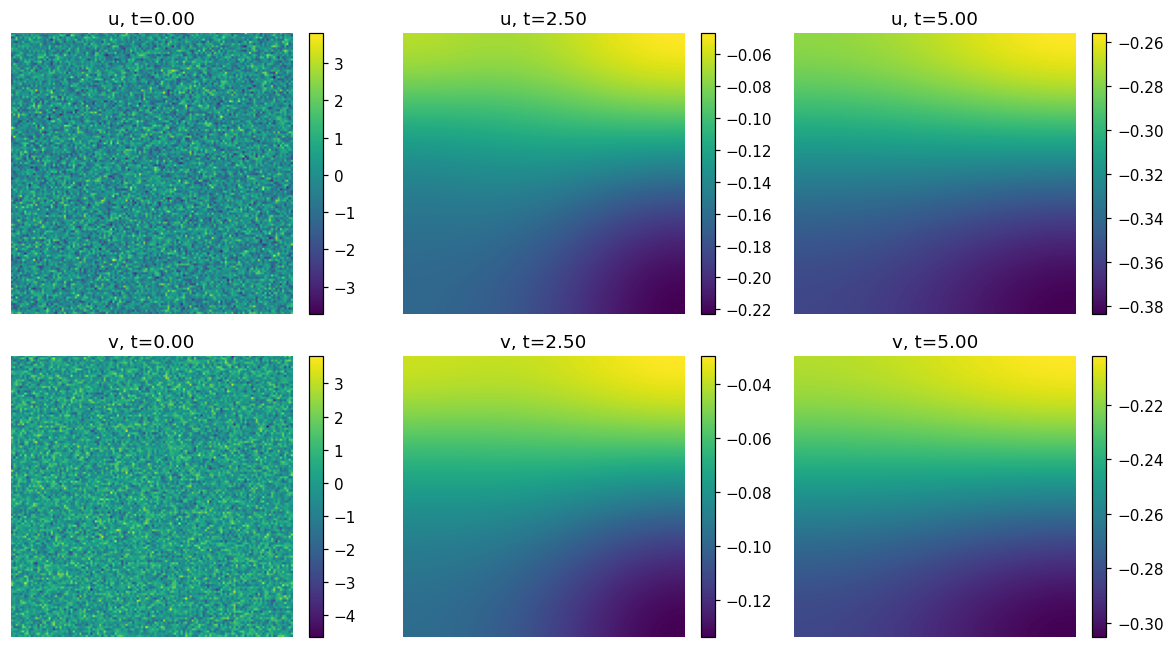

In [14]:
import matplotlib.pyplot as plt

time_ids = [0, len(t) // 2, len(t) - 1]
channel_names = ["u", "v"]

fig, axes = plt.subplots(2, 3, figsize=(11, 6))
for row, channel_name in enumerate(channel_names):
    for col, ti in enumerate(time_ids):
        ax = axes[row, col]
        im = ax.imshow(data[ti, :, :, row], origin="lower", cmap="viridis")
        ax.set_title(f"{channel_name}, t={t[ti]:.2f}")
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()


## 2. Navier-Stokes 2D, Unforced

This dataset stores unforced incompressible flow in vorticity form. Each file corresponds to one Reynolds number, and `solutions` contains many simulated trajectories for that setting.

File keys: `solutions` stores `[trajectory, time, x, y, channel]` shaped solution fields; `x-coordinate`, `y-coordinate`, and `t-coordinate` store the spatial and temporal grids.


In [15]:
from huggingface_hub import hf_hub_download

repo_id = "DabbyOWL/PDE_Inverse_Problem_Benchmarking"
ns_file = "navier-stokes-unforced-2d-64/train/107.hdf5"

ns_path = hf_hub_download(repo_id=repo_id, filename=ns_file, repo_type="dataset")
print(ns_path)


/home/divyam123/.cache/huggingface/hub/datasets--DabbyOWL--PDE_Inverse_Problem_Benchmarking/snapshots/6748e8e26f5cadb00bc3833c560c136a1bc6be82/navier-stokes-unforced-2d-64/train/107.hdf5


In [16]:
import h5py

with h5py.File(ns_path, "r") as f:
    print("top-level keys:", list(f.keys()))
    print("solutions shape:", f["solutions"].shape)
    print("x-coordinate shape:", f["x-coordinate"].shape)
    print("y-coordinate shape:", f["y-coordinate"].shape)
    print("t-coordinate shape:", f["t-coordinate"].shape)

    data = f["solutions"][0]      # first trajectory, shape: [time, x, y, channel]
    x = f["x-coordinate"][:]
    y = f["y-coordinate"][:]
    t = f["t-coordinate"][:]

print("loaded trajectory shape:", data.shape)


top-level keys: ['solutions', 't-coordinate', 'x-coordinate', 'y-coordinate']
solutions shape: (192, 64, 64, 64, 1)
x-coordinate shape: (64,)
y-coordinate shape: (64,)
t-coordinate shape: (64,)
loaded trajectory shape: (64, 64, 64, 1)


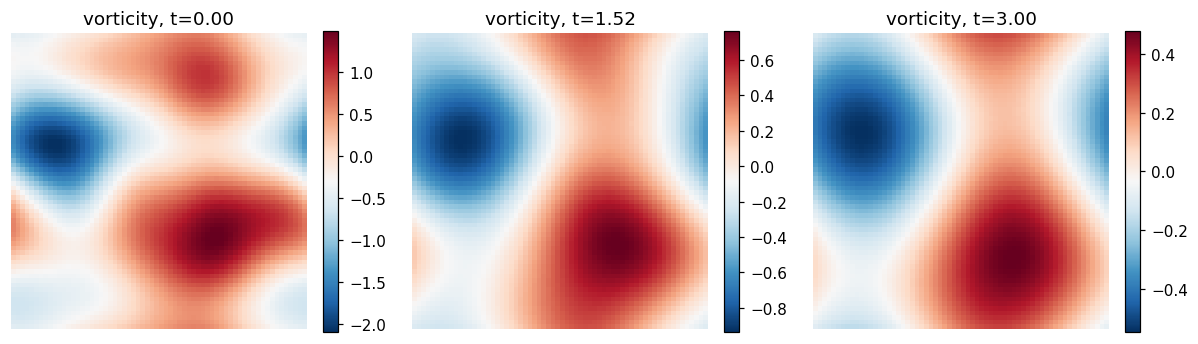

In [17]:
import matplotlib.pyplot as plt

time_ids = [0, len(t) // 2, len(t) - 1]

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
for ax, ti in zip(axes, time_ids):
    im = ax.imshow(data[ti, :, :, 0], origin="lower", cmap="RdBu_r")
    ax.set_title(f"vorticity, t={t[ti]:.2f}")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()


## 3. Turbulent Flow (2D Forced Navier-Stokes)

Turbulent Flow is a forced Navier-Stokes system with Kolmogorov forcing. The inverse parameter of interest is the viscosity `nu`, which is encoded in the filename.

File keys: top-level keys like `0000`, `0001`, ... are different trajectories. Inside each trajectory, `data` stores `[time, x, y, channel]` shaped solution fields, and `grid/x`, `grid/y`, `grid/t` store the coordinate arrays.


In [18]:
from huggingface_hub import hf_hub_download

repo_id = "DabbyOWL/PDE_Inverse_Problem_Benchmarking"
tf_file = "navier-stokes-forced-2d/train/2D_turbulent-flow_nu=0.00011756010900231849.h5"

tf_path = hf_hub_download(repo_id=repo_id, filename=tf_file, repo_type="dataset")
print(tf_path)


/home/divyam123/.cache/huggingface/hub/datasets--DabbyOWL--PDE_Inverse_Problem_Benchmarking/snapshots/6748e8e26f5cadb00bc3833c560c136a1bc6be82/navier-stokes-forced-2d/train/2D_turbulent-flow_nu=0.00011756010900231849.h5


In [19]:
import h5py

with h5py.File(tf_path, "r") as f:
    print("number of trajectory groups:", len(f.keys()))
    print("first few top-level keys:", list(f.keys())[:5])
    print("0000 keys:", list(f["0000"].keys()))
    print("0000/grid keys:", list(f["0000/grid"].keys()))

    data = f["0000/data"][:]      # shape: [time, x, y, channel]
    x = f["0000/grid/x"][:]
    y = f["0000/grid/y"][:]
    t = f["0000/grid/t"][:]

print("data shape:", data.shape)
print("x/y/t shapes:", x.shape, y.shape, t.shape)


number of trajectory groups: 108
first few top-level keys: ['0000', '0001', '0002', '0003', '0004']
0000 keys: ['data', 'grid']
0000/grid keys: ['t', 'x', 'y']
data shape: (60, 64, 64, 1)
x/y/t shapes: (64,) (64,) (60,)


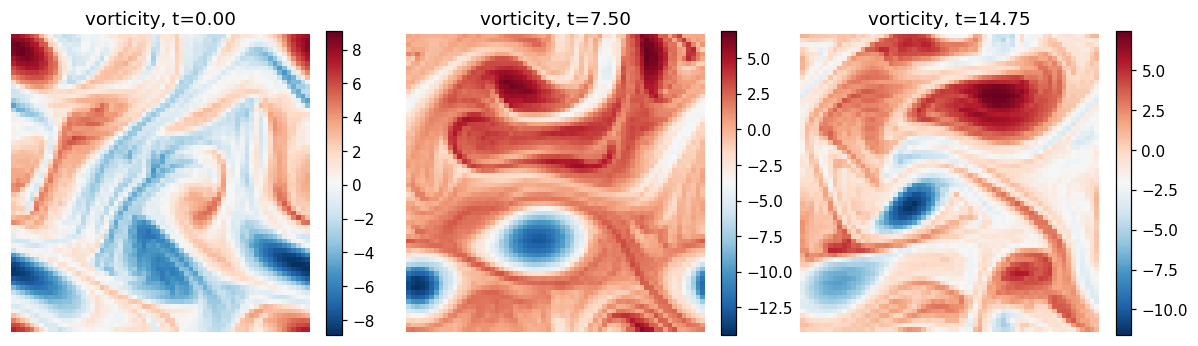

In [20]:
import matplotlib.pyplot as plt

time_ids = [0, len(t) // 2, len(t) - 1]

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
for ax, ti in zip(axes, time_ids):
    im = ax.imshow(data[ti, :, :, 0], origin="lower", cmap="RdBu_r")
    ax.set_title(f"vorticity, t={t[ti]:.2f}")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()


## 4. Korteweg-de Vries 1D

KdV is a 1D nonlinear wave equation used to model soliton-like shallow water wave dynamics. The dispersion parameter `delta` is encoded in the filename.

File keys: `tensor` stores `[trajectory, time, x]` shaped solution fields; `x-coordinate` stores the 1D spatial grid; `t-coordinate` stores the time grid.


In [21]:
from huggingface_hub import hf_hub_download

repo_id = "DabbyOWL/PDE_Inverse_Problem_Benchmarking"
kdv_file = "korteweg-de-vries-1d/train/1D_KdV_delta=0.9950917334239905_train_100.h5"

kdv_path = hf_hub_download(repo_id=repo_id, filename=kdv_file, repo_type="dataset")
print(kdv_path)


/home/divyam123/.cache/huggingface/hub/datasets--DabbyOWL--PDE_Inverse_Problem_Benchmarking/snapshots/6748e8e26f5cadb00bc3833c560c136a1bc6be82/korteweg-de-vries-1d/train/1D_KdV_delta=0.9950917334239905_train_100.h5


In [22]:
import h5py

with h5py.File(kdv_path, "r") as f:
    print("top-level keys:", list(f.keys()))
    print("tensor shape:", f["tensor"].shape)
    print("x-coordinate shape:", f["x-coordinate"].shape)
    print("t-coordinate shape:", f["t-coordinate"].shape)

    data = f["tensor"][0]         # first trajectory, shape: [time, x]
    x = f["x-coordinate"][:]
    t = f["t-coordinate"][:]

print("loaded trajectory shape:", data.shape)


top-level keys: ['t-coordinate', 'tensor', 'x-coordinate']
tensor shape: (100, 140, 256)
x-coordinate shape: (256,)
t-coordinate shape: (140,)
loaded trajectory shape: (140, 256)


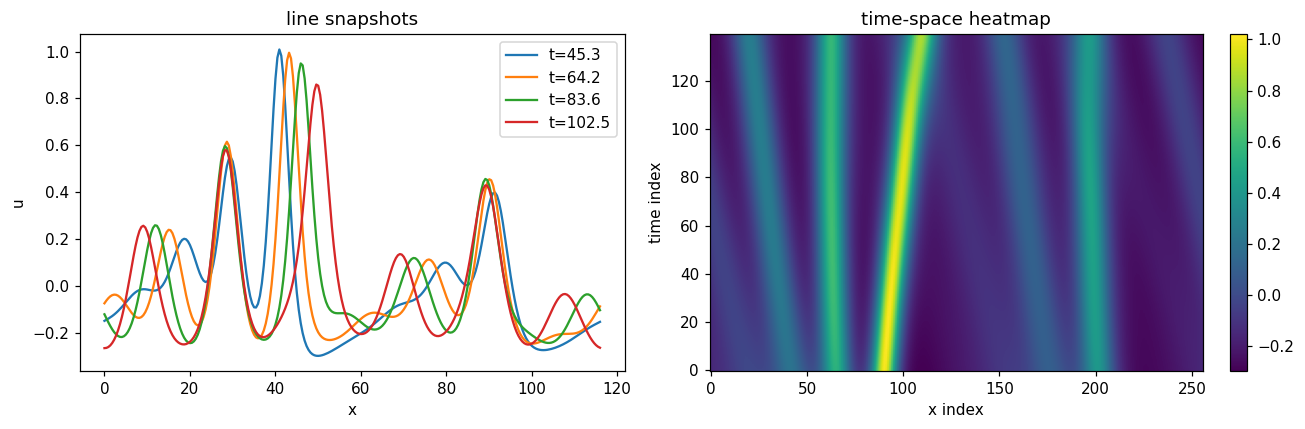

In [ ]:
import matplotlib.pyplot as plt

time_ids = [0, len(t) // 3, 2 * len(t) // 3, len(t) - 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ti in time_ids:
    axes[0].plot(x, data[ti], label=f"t={t[ti]:.1f}")
axes[0].set_title("trajectory snapshots")
axes[0].set_xlabel("x")
axes[0].set_ylabel("u")
axes[0].legend()

im = axes[1].imshow(data, aspect="auto", origin="lower", cmap="viridis")
axes[1].set_title("time-space heatmap")
axes[1].set_xlabel("x index")
axes[1].set_ylabel("time index")
plt.colorbar(im, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()


## 5. Darcy Flow 2D

Darcy Flow is a steady-state elliptic PDE for flow through porous media. The coefficient field controls permeability, and the solution field is the resulting pressure-like state.

File keys: `coeff` stores the coefficient field and `sol` stores the solution field. `kcoeff` stores the smoothed coefficient field, while `kcoeff_x` and `kcoeff_y` store its spatial derivatives.



In [24]:
from huggingface_hub import hf_hub_download

repo_id = "DabbyOWL/PDE_Inverse_Problem_Benchmarking"
darcy_file = "darcy-flow-241/train/darcy_flow_1.h5"

darcy_path = hf_hub_download(repo_id=repo_id, filename=darcy_file, repo_type="dataset")
print(darcy_path)


/home/divyam123/.cache/huggingface/hub/datasets--DabbyOWL--PDE_Inverse_Problem_Benchmarking/snapshots/6748e8e26f5cadb00bc3833c560c136a1bc6be82/darcy-flow-241/train/darcy_flow_1.h5


In [25]:
import h5py
import numpy as np

with h5py.File(darcy_path, "r") as f:
    print("top-level keys:", list(f.keys()))
    print("coeff shape:", f["coeff"].shape)
    print("sol shape:", f["sol"].shape)

    coeff = f["coeff"][:, :, 0]
    sol = f["sol"][:, :, 0]

print("loaded coeff shape:", coeff.shape)
print("loaded sol shape:", sol.shape)
print("coefficient values:", np.unique(coeff))


top-level keys: ['coeff', 'kcoeff', 'kcoeff_x', 'kcoeff_y', 'sol']
coeff shape: (241, 241, 1)
sol shape: (241, 241, 1)
loaded coeff shape: (241, 241)
loaded sol shape: (241, 241)
coefficient values: [ 3. 12.]


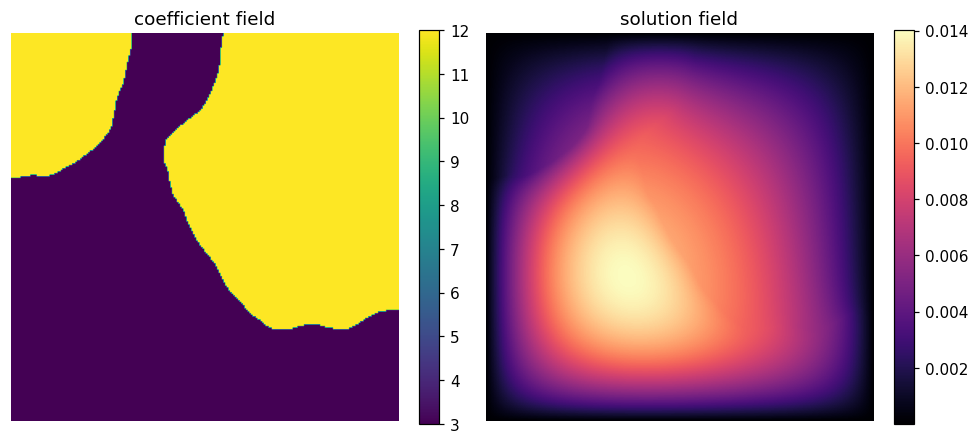

In [26]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

im0 = axes[0].imshow(coeff, origin="lower", cmap="viridis")
axes[0].set_title("coefficient field")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(sol, origin="lower", cmap="magma")
axes[1].set_title("solution field")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()
